In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# import tensorflow as tf
# import numpy as np
# from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
# import seaborn as sns

import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras import layers
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, average_precision_score, f1_score



In [ ]:
# ====================
# CONFIG
# ====================
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 16
IMAGE_SIZE = (224, 224)
EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

In [ ]:
# ====================
# LOAD DATASET (whole dataset, no split)
# ====================
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    '/content/drive/My Drive/ROP-Data/images_stack/split_dataset',
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    shuffle=False  # IMPORTANT: Keep order for matching labels to predictions
)

class_names = dataset.class_names
print("Class names:", class_names)


Dataset distribution:
Negative: 128 images
Positive: 60 images


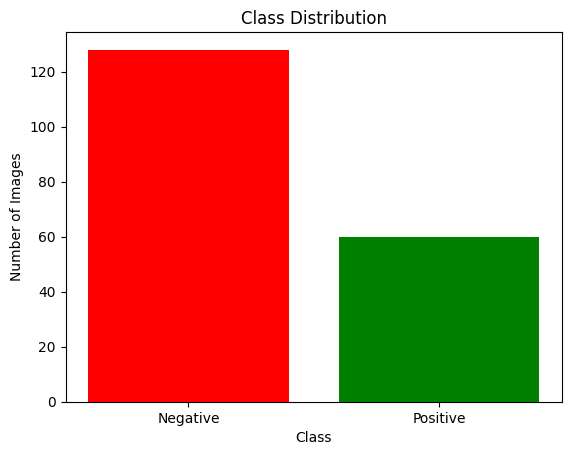

In [ ]:
# ====================
# CLASS DISTRIBUTION
# ====================
class_counts = {name: 0 for name in class_names}
for _, labels in dataset:
    for label in labels.numpy():
        class_counts[class_names[label]] += 1

print("\nDataset distribution:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count} images")

# Plot bar chart
plt.bar(class_counts.keys(), class_counts.values(), color=['red', 'green'])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

#Split Dataset (In case training is needed - stratified)

In [ ]:
import os
import pathlib
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

In [ ]:
def stratified_splits_from_dir(root_dir, train=0.7, val=0.1, test=0.2, seed=42):
    """
    Stratified split of data into train, validation, and test sets while maintaining class balance.
    """
    root = pathlib.Path(root_dir)
    # Get class names (folder names)
    class_names = sorted([d.name for d in root.iterdir() if d.is_dir()])
    paths, labels = [], []
    for idx, cname in enumerate(class_names):
        for p in (root / cname).rglob('*'):
            if p.suffix.lower() in EXTS:
                paths.append(str(p))
                labels.append(idx)

    X = np.array(paths)
    y = np.array(labels)

    # Perform stratified split: train vs temp (val + test)
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=(val+test), stratify=y, random_state=seed)

    # Split temp into validation and test sets
    val_prop = val / (val + test)  # Proportion of validation in temp
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=(1 - val_prop), stratify=y_temp, random_state=seed)

    return (X_train, y_train), (X_val, y_val), (X_test, y_test), class_names

def paths_to_dataset(paths, labels, image_size, batch_size, training=False):
    """
    Convert file paths to TensorFlow dataset.
    """
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        # Shuffle the dataset for training
        ds = ds.shuffle(len(paths), reshuffle_each_iteration=True)

    def _load_image(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, image_size)
        img = tf.cast(img, tf.float32)
        return img, label

    # Map the function, batch, cache, and prefetch
    ds = ds.map(_load_image, num_parallel_calls=AUTOTUNE).batch(batch_size).cache().prefetch(AUTOTUNE)

    return ds

def get_stratified_datasets(root_dir, image_size=(224, 224), batch_size=32, seed=42, train_split=0.7, val_split=0.1, test_split=0.2):
    """
    Get the train, validation, and test datasets in a stratified manner.
    """
    # Get stratified splits
    (X_train, y_train), (X_val, y_val), (X_test, y_test), class_names = stratified_splits_from_dir(
        root_dir, train=train_split, val=val_split, test=test_split, seed=seed)

    # Convert paths to datasets
    train_ds = paths_to_dataset(X_train, y_train, image_size, batch_size, training=True)
    val_ds = paths_to_dataset(X_val, y_val, image_size, batch_size, training=False)
    test_ds = paths_to_dataset(X_test, y_test, image_size, batch_size, training=False)

    print("Stratified split counts:")
    print(" Train:", dict(zip(class_names, np.bincount(y_train))))
    print(" Validation:", dict(zip(class_names, np.bincount(y_val))))
    print(" Test:", dict(zip(class_names, np.bincount(y_test))))

    return train_ds, val_ds, test_ds, class_names


In [ ]:
train_ds, val_ds, test_ds, class_names = get_stratified_datasets(
    root_dir='/content/drive/My Drive/ROP-Data/images_stack/split_dataset',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=42,
    train_split=0.6,
    val_split=0.1,
    test_split=0.3
)

Stratified split counts:
 Train: {'Negative': np.int64(76), 'Positive': np.int64(36)}
 Validation: {'Negative': np.int64(13), 'Positive': np.int64(6)}
 Test: {'Negative': np.int64(39), 'Positive': np.int64(18)}


In [ ]:
# # ---------- 1) Split ----------
# train_ds, val_ds, test_ds = get_partitioned_datasets(dataset, train_split=0.7, val_split=0.1, test_split=0.2, shuffle=True, shuffle_size=10000)

# # Grab class names and verify binary
# class_names = dataset.class_names  # inherited from the original dataset
# num_classes = len(class_names)
# assert num_classes == 2, f"Expected binary dataset, found {num_classes} classes: {class_names}"

# print("Classes:", class_names)

In [ ]:
# ---------- 2) Performance niceties ----------
def prepare(ds, training=False):
    # Cache > shuffle (only for training) > prefetch
    if training:
        ds = ds.shuffle(1000)
    return ds.cache().prefetch(AUTOTUNE)

In [ ]:
def count_labels(ds, num_classes):

    counts = np.zeros(num_classes, dtype=np.int64)
    for batch_images, batch_labels in ds:
        # Ensure labels are in the expected format (integers, not one-hot)
        values, nums = np.unique(batch_labels.numpy(), return_counts=True)
        for v, n in zip(values, nums):
            counts[int(v)] += int(n)
    return counts

# Assuming num_classes = 2 for your case (Negative=0, Positive=1)
num_classes = 2

# Count the labels in the training set
train_counts = count_labels(train_ds, num_classes)

# Get total number of samples in the training set
total_train = int(train_counts.sum())

# Get the number of negative and positive samples
neg_count, pos_count = int(train_counts[0]), int(train_counts[1])

# Print the class counts for validation
print(f"Train counts -> {class_names[0]}: {neg_count}, {class_names[1]}: {pos_count}")

# Calculate inverse-frequency class weights
# This ensures that the minority class gets more weight during training
class_weight = {
    0: total_train / (2.0 * max(neg_count, 1)),
    1: total_train / (2.0 * max(pos_count, 1)),
}

# Print the calculated class weights
print("Class weights:", class_weight)

Train counts -> Negative: 76, Positive: 36
Class weights: {0: 0.7368421052631579, 1: 1.5555555555555556}


#**ResNet50** (Fully Frozed -> binary classification head)

---

Classification Report:

                  precision    recall  f1-score   support

    Negative       0.78      0.97      0.86        39
    Positive       0.88      0.39      0.54        18

    accuracy                               0.79        57
    macro avg          0.83      0.68      0.70        57
    weighted avg       0.81      0.79      0.76        57


In [ ]:
# ---------- 4) Preprocessing & augmentation ----------
# ResNet50 expects preprocess_input
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="augmentation")

def preprocess_batch(images, labels, training=False):
    if training:
        images = data_augmentation(images, training=True)
    images = preprocess_input(images)  # converts to mode expected by ResNet
    return images, labels

train_prep = train_ds.map(lambda x, y: preprocess_batch(x, y, training=True), num_parallel_calls=AUTOTUNE)
val_prep   = val_ds.map(lambda x, y: preprocess_batch(x, y, training=False), num_parallel_calls=AUTOTUNE)
test_prep  = test_ds.map(lambda x, y: preprocess_batch(x, y, training=False), num_parallel_calls=AUTOTUNE)

train_prep = prepare(train_prep, training=True)
val_prep   = prepare(val_prep)
test_prep  = prepare(test_prep)


In [ ]:
# ---------- 5) Build frozen-ResNet50 model ----------
# Tip: Keep input shape (224,224,3)
inputs = layers.Input(shape=(*IMAGE_SIZE, 3))
x = inputs

x = layers.Lambda(preprocess_input, name="resnet_preproc")(x)

base = ResNet50(include_top=False, weights='imagenet', input_tensor=x, pooling='avg')
base.trainable = False  # freeze the backbone

# Small classifier head
x = base.output
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid', name='classifier')(x)

model = keras.Model(inputs=inputs, outputs=outputs)
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet_preproc      │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ resnet_preproc[0… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# ---------- 6) Compile ----------
metrics = [
    keras.metrics.AUC(name="auc_roc", curve="ROC"),
    keras.metrics.AUC(name="auc_pr", curve="PR"),
    keras.metrics.Precision(name="precision"),
    keras.metrics.Recall(name="recall"),
]
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=metrics
)

In [ ]:
# ---------- 7) Train ----------
early = keras.callbacks.EarlyStopping(
    monitor="val_auc_pr",  # PR-AUC is sensitive to imbalance
    mode="max",
    patience=8,
    restore_best_weights=True
)

history = model.fit(
    train_prep,
    validation_data=val_prep,
    epochs=50,
    class_weight=class_weight,
    callbacks=[early],
    verbose=2
)

Epoch 1/50
7/7 - 43s - 6s/step - auc_pr: 0.3464 - auc_roc: 0.5084 - loss: 0.8579 - precision: 0.3158 - recall: 0.5000 - val_auc_pr: 0.2937 - val_auc_roc: 0.5064 - val_loss: 0.8206 - val_precision: 0.3125 - val_recall: 0.8333
Epoch 2/50
7/7 - 35s - 5s/step - auc_pr: 0.4712 - auc_roc: 0.6510 - loss: 0.6950 - precision: 0.4138 - recall: 0.6667 - val_auc_pr: 0.3154 - val_auc_roc: 0.5641 - val_loss: 0.6223 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/50
7/7 - 25s - 4s/step - auc_pr: 0.4060 - auc_roc: 0.5932 - loss: 0.7539 - precision: 0.4146 - recall: 0.4722 - val_auc_pr: 0.4583 - val_auc_roc: 0.6731 - val_loss: 0.6011 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/50
7/7 - 25s - 4s/step - auc_pr: 0.4823 - auc_roc: 0.6689 - loss: 0.6849 - precision: 0.4898 - recall: 0.6667 - val_auc_pr: 0.4487 - val_auc_roc: 0.6538 - val_loss: 0.5999 - val_precision: 0.5000 - val_recall: 0.1667
Epoch 5/50
7/7 - 44s - 6s/step - auc_pr: 0.5182 - auc_roc: 0.7319 - loss: 0.6140 - p

In [ ]:
# ---------- 8) Evaluate on test set ----------
eval_res = model.evaluate(test_prep, verbose=0)
print({m: v for m, v in zip(model.metrics_names, eval_res)})

# Collect predictions & compute extra metrics (F1, confusion matrix)
y_true = []
y_prob = []
for batch_x, batch_y in test_prep:
    y_true.append(batch_y.numpy())
    y_prob.append(model.predict(batch_x, verbose=0).ravel())

y_true = np.concatenate(y_true)
y_prob = np.concatenate(y_prob)
y_pred = (y_prob >= 0.5).astype(int)

# Metrics
roc = roc_auc_score(y_true, y_prob)
pr_auc = average_precision_score(y_true, y_prob)
f1 = f1_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print("\nTest Metrics (threshold=0.5):")
print(f"ROC-AUC: {roc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")
print(f"F1:      {f1:.4f}")
print("\nConfusion Matrix [ [TN, FP], [FN, TP] ]:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

{'loss': 0.5340778231620789, 'compile_metrics': 0.7649572491645813}

Test Metrics (threshold=0.5):
ROC-AUC: 0.7678
PR-AUC:  0.6738
F1:      0.5385

Confusion Matrix [ [TN, FP], [FN, TP] ]:
[[38  1]
 [11  7]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.78      0.97      0.86        39
    Positive       0.88      0.39      0.54        18

    accuracy                           0.79        57
   macro avg       0.83      0.68      0.70        57
weighted avg       0.81      0.79      0.76        57



#**EfficientNetB0** (Fully Frozed -> binary classifier head)

---
Confusion Matrix

    [ [TN, FP], [FN, TP] ] :  [[27 12] ,[ 9  9]]

Classification Report:

              precision    recall  f1-score   support

    Negative       0.75      0.69      0.72        39
    Positive       0.43      0.50      0.46        18

    accuracy                               0.63        57
    macro avg          0.59      0.60      0.59        57
    weighted avg       0.65      0.63      0.64        57


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, average_precision_score, f1_score


In [ ]:
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="augmentation")

def preprocess_batch(images, labels, training=False):
    if training:
        images = data_augmentation(images, training=True)
    images = preprocess_input(images)  # EfficientNet-specific preprocessing
    return images, labels

train_prep = train_ds.map(lambda x, y: preprocess_batch(x, y, training=True), num_parallel_calls=AUTOTUNE)
val_prep = val_ds.map(lambda x, y: preprocess_batch(x, y, training=False), num_parallel_calls=AUTOTUNE)
test_prep = test_ds.map(lambda x, y: preprocess_batch(x, y, training=False), num_parallel_calls=AUTOTUNE)

train_prep = prepare(train_prep, training=True)
val_prep = prepare(val_prep)
test_prep = prepare(test_prep)

In [ ]:
# ---------- 5) Build frozen-EfficientNetB0 model ----------
# Tip: Keep input shape (224,224,3)
inputs = layers.Input(shape=(*IMAGE_SIZE, 3))
x = inputs
x = layers.Lambda(preprocess_input, name="efficientnet_preproc")(x)
base = EfficientNetB0(include_top=False, weights='imagenet', input_tensor=x, pooling='avg')
base.trainable = False  # Freeze the backbone
x = base.output
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid', name='classifier')(x)
model = keras.Model(inputs=inputs, outputs=outputs)
model.summary()


Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_21      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnet_prepr… │ (None, 224, 224,  │          0 │ input_layer_21[0… │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_12        │ (None, 224, 224,  │          0 │ efficientnet_pre… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_6     │ (None, 224, 224,  │          7 │ rescaling_12[0][… │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_13        │ (None, 224, 224,  │          0 │ normalization_6[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_13[0][… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
# ---------- 6) Compile ----------
metrics = [
    keras.metrics.AUC(name="auc_roc", curve="ROC"),
    keras.metrics.AUC(name="auc_pr", curve="PR"),
    keras.metrics.Precision(name="precision"),
    keras.metrics.Recall(name="recall"),
]
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=metrics
)


In [ ]:
# ---------- 7) Train ----------
early = keras.callbacks.EarlyStopping(
    monitor="val_auc_pr",  # PR-AUC is sensitive to imbalance
    mode="max",
    patience=8,
    restore_best_weights=True
)
history = model.fit(
    train_prep,
    validation_data=val_prep,
    epochs=50,
    class_weight=class_weight,
    callbacks=[early],
    verbose=2
)

Epoch 1/50
7/7 - 33s - 5s/step - auc_pr: 0.3655 - auc_roc: 0.5934 - loss: 0.6850 - precision: 0.3636 - recall: 0.5556 - val_auc_pr: 0.2508 - val_auc_roc: 0.4038 - val_loss: 0.7231 - val_precision: 0.3571 - val_recall: 0.8333
Epoch 2/50
7/7 - 9s - 1s/step - auc_pr: 0.5318 - auc_roc: 0.7864 - loss: 0.6098 - precision: 0.5526 - recall: 0.5833 - val_auc_pr: 0.2719 - val_auc_roc: 0.4679 - val_loss: 0.6979 - val_precision: 0.2727 - val_recall: 0.5000
Epoch 3/50
7/7 - 11s - 2s/step - auc_pr: 0.5708 - auc_roc: 0.7489 - loss: 0.6235 - precision: 0.5581 - recall: 0.6667 - val_auc_pr: 0.2907 - val_auc_roc: 0.5000 - val_loss: 0.6938 - val_precision: 0.2222 - val_recall: 0.3333
Epoch 4/50
7/7 - 18s - 3s/step - auc_pr: 0.7196 - auc_roc: 0.7984 - loss: 0.5776 - precision: 0.5957 - recall: 0.7778 - val_auc_pr: 0.4245 - val_auc_roc: 0.5321 - val_loss: 0.6828 - val_precision: 0.1429 - val_recall: 0.1667
Epoch 5/50
7/7 - 10s - 1s/step - auc_pr: 0.6270 - auc_roc: 0.7891 - loss: 0.5783 - precision: 0.5111 

In [ ]:
eval_res = model.evaluate(test_prep, verbose=0)
print({m: v for m, v in zip(model.metrics_names, eval_res)})

# Collect predictions & compute extra metrics
y_true = []
y_prob = []
for batch_x, batch_y in test_prep:
    y_true.append(batch_y.numpy())
    y_prob.append(model.predict(batch_x, verbose=0).ravel())
y_true = np.concatenate(y_true)
y_prob = np.concatenate(y_prob)
y_pred = (y_prob >= 0.5).astype(int)

# Metrics
roc = roc_auc_score(y_true, y_prob)
pr_auc = average_precision_score(y_true, y_prob)
f1 = f1_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)
print("\nTest Metrics (threshold=0.5):")
print(f"ROC-AUC: {roc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")
print(f"F1:      {f1:.4f}")
print("\nConfusion Matrix [ [TN, FP], [FN, TP] ]:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

{'loss': 0.6281906366348267, 'compile_metrics': 0.6495726704597473}

Test Metrics (threshold=0.5):
ROC-AUC: 0.6496
PR-AUC:  0.6576
F1:      0.4615

Confusion Matrix [ [TN, FP], [FN, TP] ]:
[[27 12]
 [ 9  9]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.75      0.69      0.72        39
    Positive       0.43      0.50      0.46        18

    accuracy                           0.63        57
   macro avg       0.59      0.60      0.59        57
weighted avg       0.65      0.63      0.64        57



#**MobileNeV2** (Fully Frozed -> binary classifier head)

---
Confusion Matrix

    [ [TN, FP], [FN, TP] ]: [[30  9] ,[11  7]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.73      0.77      0.75        39
    Positive       0.44      0.39      0.41        18

    accuracy                               0.65        57
    macro avg          0.58      0.58      0.58        57
    weighted avg       0.64      0.65      0.64        57



In [ ]:
# Preprocessing & Augmentation
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="augmentation")

def preprocess_batch(images, labels, training=False):
    if training:
        images = data_augmentation(images, training=True)
    images = preprocess_input(images)  # MobileNetV2-specific preprocessing
    return images, labels

train_prep = train_ds.map(lambda x, y: preprocess_batch(x, y, training=True), num_parallel_calls=AUTOTUNE)
val_prep = val_ds.map(lambda x, y: preprocess_batch(x, y, training=False), num_parallel_calls=AUTOTUNE)
test_prep = test_ds.map(lambda x, y: preprocess_batch(x, y, training=False), num_parallel_calls=AUTOTUNE)

train_prep = prepare(train_prep, training=True)
val_prep = prepare(val_prep)
test_prep = prepare(test_prep)

In [ ]:
# ====================
# Build Frozen MobileNetV2 Model
# ====================
inputs = layers.Input(shape=(*IMAGE_SIZE, 3))
x = inputs
x = layers.Lambda(preprocess_input, name="mobilenet_preproc")(x)
base = MobileNetV2(include_top=False, weights='imagenet', input_tensor=x, pooling='avg')
base.trainable = False  # Freeze the backbone
x = base.output
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid', name='classifier')(x)
model = keras.Model(inputs=inputs, outputs=outputs)
model.summary()


/tmp/ipython-input-836034634.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(include_top=False, weights='imagenet', input_tensor=x, pooling='avg')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_23      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenet_preproc   │ (None, 224, 224,  │          0 │ input_layer_23[0… │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ mobilenet_prepro… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# ====================
# Compile
# ====================
metrics = [
    keras.metrics.AUC(name="auc_roc", curve="ROC"),
    keras.metrics.AUC(name="auc_pr", curve="PR"),
    keras.metrics.Precision(name="precision"),
    keras.metrics.Recall(name="recall"),
]
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=metrics
)

In [ ]:
# ====================
# Train
# ====================
early = keras.callbacks.EarlyStopping(
    monitor="val_auc_pr",  # PR-AUC is sensitive to imbalance
    mode="max",
    patience=8,
    restore_best_weights=True
)
history = model.fit(
    train_prep,
    validation_data=val_prep,
    epochs=50,
    class_weight=class_weight,
    callbacks=[early],
    verbose=2
)


Epoch 1/50
7/7 - 24s - 3s/step - auc_pr: 0.3739 - auc_roc: 0.5938 - loss: 0.7070 - precision: 0.3770 - recall: 0.6389 - val_auc_pr: 0.2574 - val_auc_roc: 0.4295 - val_loss: 0.6236 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
7/7 - 12s - 2s/step - auc_pr: 0.3800 - auc_roc: 0.5223 - loss: 0.7434 - precision: 0.4091 - recall: 0.2500 - val_auc_pr: 0.2490 - val_auc_roc: 0.3846 - val_loss: 0.6876 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/50
7/7 - 12s - 2s/step - auc_pr: 0.3151 - auc_roc: 0.4868 - loss: 0.7335 - precision: 0.3333 - recall: 0.6667 - val_auc_pr: 0.2622 - val_auc_roc: 0.4167 - val_loss: 0.7584 - val_precision: 0.3158 - val_recall: 1.0000
Epoch 4/50
7/7 - 10s - 1s/step - auc_pr: 0.3514 - auc_roc: 0.5154 - loss: 0.7324 - precision: 0.3378 - recall: 0.6944 - val_auc_pr: 0.2753 - val_auc_roc: 0.4615 - val_loss: 0.6672 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/50
7/7 - 9s - 1s/step - auc_pr: 0.3367 - auc_roc: 0.5192 - loss: 0.7

In [ ]:
# ====================
# Evaluate on Test Set
# ====================
eval_res = model.evaluate(test_prep, verbose=0)
print({m: v for m, v in zip(model.metrics_names, eval_res)})

# Collect predictions & compute extra metrics
y_true = []
y_prob = []
for batch_x, batch_y in test_prep:
    y_true.append(batch_y.numpy())
    y_prob.append(model.predict(batch_x, verbose=0).ravel())
y_true = np.concatenate(y_true)
y_prob = np.concatenate(y_prob)
y_pred = (y_prob >= 0.5).astype(int)

# Metrics
roc = roc_auc_score(y_true, y_prob)
pr_auc = average_precision_score(y_true, y_prob)
f1 = f1_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)
print("\nTest Metrics (threshold=0.5):")
print(f"ROC-AUC: {roc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")
print(f"F1:      {f1:.4f}")
print("\nConfusion Matrix [ [TN, FP], [FN, TP] ]:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

{'loss': 0.6823599338531494, 'compile_metrics': 0.5562677979469299}



Test Metrics (threshold=0.5):
ROC-AUC: 0.5385
PR-AUC:  0.3815
F1:      0.4118

Confusion Matrix [ [TN, FP], [FN, TP] ]:
[[30  9]
 [11  7]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.73      0.77      0.75        39
    Positive       0.44      0.39      0.41        18

    accuracy                           0.65        57
   macro avg       0.58      0.58      0.58        57
weighted avg       0.64      0.65      0.64        57



#**DenseNet** (Fully Frozed -> binary classification head)

---
Confusion Matrix

    [ [TN, FP], [FN, TP] ]: [[22 17] ,[ 8 10]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.73      0.56      0.64        39
    Positive       0.37      0.56      0.44        18

    accuracy                               0.56        57
    macro avg          0.55      0.56      0.54        57
    weighted avg       0.62      0.56      0.58        57


In [ ]:
# ====================
# Preprocessing & Augmentation
# ====================
from tensorflow.keras.applications.densenet import DenseNet121, preprocess_input

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="augmentation")

def preprocess_batch(images, labels, training=False):
    if training:
        images = data_augmentation(images, training=True)
    images = preprocess_input(images)  # DenseNet121-specific preprocessing
    return images, labels

train_prep = train_ds.map(lambda x, y: preprocess_batch(x, y, training=True), num_parallel_calls=AUTOTUNE)
val_prep = val_ds.map(lambda x, y: preprocess_batch(x, y, training=False), num_parallel_calls=AUTOTUNE)
test_prep = test_ds.map(lambda x, y: preprocess_batch(x, y, training=False), num_parallel_calls=AUTOTUNE)

train_prep = prepare(train_prep, training=True)
val_prep = prepare(val_prep)
test_prep = prepare(test_prep)

In [ ]:
# ====================
# Build Frozen DenseNet121 Model
# ====================
inputs = layers.Input(shape=(*IMAGE_SIZE, 3))
x = inputs
x = layers.Lambda(preprocess_input, name="densenet_preproc")(x)
base = DenseNet121(include_top=False, weights='imagenet', input_tensor=x, pooling='avg')
base.trainable = False  # Freeze the backbone
x = base.output
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid', name='classifier')(x)
model = keras.Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet_preproc    │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, 230, 230,  │          0 │ densenet_preproc… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_3    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_3… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b

 Total params: 7,038,529 (26.85 MB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
# ====================
# Compile
# ====================
metrics = [
    keras.metrics.AUC(name="auc_roc", curve="ROC"),
    keras.metrics.AUC(name="auc_pr", curve="PR"),
    keras.metrics.Precision(name="precision"),
    keras.metrics.Recall(name="recall"),
]
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=metrics
)


In [ ]:
# ====================
# Train
# ====================
early = keras.callbacks.EarlyStopping(
    monitor="val_auc_pr",  # PR-AUC is sensitive to imbalance
    mode="max",
    patience=8,
    restore_best_weights=True
)
history = model.fit(
    train_prep,
    validation_data=val_prep,
    epochs=50,
    class_weight=class_weight,
    callbacks=[early],
    verbose=2
)


Epoch 1/50
7/7 - 53s - 8s/step - auc_pr: 0.3532 - auc_roc: 0.5528 - loss: 0.8197 - precision: 0.2500 - recall: 0.0278 - val_auc_pr: 0.2538 - val_auc_roc: 0.3782 - val_loss: 0.6460 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
7/7 - 20s - 3s/step - auc_pr: 0.2768 - auc_roc: 0.3962 - loss: 0.7854 - precision: 0.2857 - recall: 0.2222 - val_auc_pr: 0.2675 - val_auc_roc: 0.3846 - val_loss: 0.7382 - val_precision: 0.3529 - val_recall: 1.0000
Epoch 3/50
7/7 - 20s - 3s/step - auc_pr: 0.3585 - auc_roc: 0.5671 - loss: 0.6959 - precision: 0.3478 - recall: 0.6667 - val_auc_pr: 0.2741 - val_auc_roc: 0.4103 - val_loss: 0.8031 - val_precision: 0.3158 - val_recall: 1.0000
Epoch 4/50
7/7 - 22s - 3s/step - auc_pr: 0.3545 - auc_roc: 0.5477 - loss: 0.7150 - precision: 0.3544 - recall: 0.7778 - val_auc_pr: 0.3883 - val_auc_roc: 0.4167 - val_loss: 0.7747 - val_precision: 0.3158 - val_recall: 1.0000
Epoch 5/50
7/7 - 42s - 6s/step - auc_pr: 0.3858 - auc_roc: 0.5208 - loss: 0.6995 - precision

In [ ]:
# ====================
# Evaluate on Test Set
# ====================
eval_res = model.evaluate(test_prep, verbose=0)
print({m: v for m, v in zip(model.metrics_names, eval_res)})

# Collect predictions & compute extra metrics
y_true = []
y_prob = []
for batch_x, batch_y in test_prep:
    y_true.append(batch_y.numpy())
    y_prob.append(model.predict(batch_x, verbose=0).ravel())
y_true = np.concatenate(y_true)
y_prob = np.concatenate(y_prob)
y_pred = (y_prob >= 0.5).astype(int)

# Metrics
roc = roc_auc_score(y_true, y_prob)
pr_auc = average_precision_score(y_true, y_prob)
f1 = f1_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)
print("\nTest Metrics (threshold=0.5):")
print(f"ROC-AUC: {roc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")
print(f"F1:      {f1:.4f}")
print("\nConfusion Matrix [ [TN, FP], [FN, TP] ]:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

{'loss': 0.6534247994422913, 'compile_metrics': 0.6374644041061401}

Test Metrics (threshold=0.5):
ROC-AUC: 0.6368
PR-AUC:  0.4110
F1:      0.4444

Confusion Matrix [ [TN, FP], [FN, TP] ]:
[[22 17]
 [ 8 10]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.73      0.56      0.64        39
    Positive       0.37      0.56      0.44        18

    accuracy                           0.56        57
   macro avg       0.55      0.56      0.54        57
weighted avg       0.62      0.56      0.58        57



#**InceptionV3** (Fully Frozed -> binary classification head)

---
Confusion Matrix

    [ [TN, FP], [FN, TP] ]: [[29 10] ,[10  8]]

Classification Report:
              
              precision    recall  f1-score   support

    Negative       0.74      0.74      0.74        39
    Positive       0.44      0.44      0.44        18

    accuracy                               0.65        57
    macro avg          0.59      0.59      0.59        57
    weighted avg       0.65      0.65      0.65        57


In [ ]:
# ====================
# Preprocessing & Augmentation
# ====================
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="augmentation")

def preprocess_batch(images, labels, training=False):
    if training:
        images = data_augmentation(images, training=True)
    images = preprocess_input(images)  # InceptionV3-specific preprocessing
    return images, labels

train_prep = train_ds.map(lambda x, y: preprocess_batch(x, y, training=True), num_parallel_calls=AUTOTUNE)
val_prep = val_ds.map(lambda x, y: preprocess_batch(x, y, training=False), num_parallel_calls=AUTOTUNE)
test_prep = test_ds.map(lambda x, y: preprocess_batch(x, y, training=False), num_parallel_calls=AUTOTUNE)

train_prep = prepare(train_prep, training=True)
val_prep = prepare(val_prep)
test_prep = prepare(test_prep)

In [ ]:
# ====================
# Build Frozen InceptionV3 Model
# ====================
inputs = layers.Input(shape=(*IMAGE_SIZE, 3))
x = inputs
x = layers.Lambda(preprocess_input, name="inception_preproc")(x)
base = InceptionV3(include_top=False, weights='imagenet', input_tensor=x, pooling='avg')
base.trainable = False  # Freeze the backbone
x = base.output
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid', name='classifier')(x)
model = keras.Model(inputs=inputs, outputs=outputs)
model.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_preproc   │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 111, 111,  │        864 │ inception_prepro… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 52, 52,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_4[0][0]  

 Total params: 21,804,833 (83.18 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [ ]:
# ====================
# Compile
# ====================
metrics = [
    keras.metrics.AUC(name="auc_roc", curve="ROC"),
    keras.metrics.AUC(name="auc_pr", curve="PR"),
    keras.metrics.Precision(name="precision"),
    keras.metrics.Recall(name="recall"),
]
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=metrics
)


In [ ]:
# ====================
# Train
# ====================
early = keras.callbacks.EarlyStopping(
    monitor="val_auc_pr",  # PR-AUC is sensitive to imbalance
    mode="max",
    patience=8,
    restore_best_weights=True
)
history = model.fit(
    train_prep,
    validation_data=val_prep,
    epochs=50,
    class_weight=class_weight,
    callbacks=[early],
    verbose=2
)


Epoch 1/50
7/7 - 28s - 4s/step - auc_pr: 0.3025 - auc_roc: 0.4337 - loss: 0.7125 - precision: 0.2500 - recall: 0.3333 - val_auc_pr: 0.2064 - val_auc_roc: 0.2179 - val_loss: 0.7163 - val_precision: 0.3125 - val_recall: 0.8333
Epoch 2/50
7/7 - 16s - 2s/step - auc_pr: 0.3145 - auc_roc: 0.5345 - loss: 0.6918 - precision: 0.3651 - recall: 0.6389 - val_auc_pr: 0.2186 - val_auc_roc: 0.2756 - val_loss: 0.7020 - val_precision: 0.2857 - val_recall: 0.6667
Epoch 3/50
7/7 - 20s - 3s/step - auc_pr: 0.3552 - auc_roc: 0.4854 - loss: 0.6992 - precision: 0.3077 - recall: 0.5556 - val_auc_pr: 0.2364 - val_auc_roc: 0.3526 - val_loss: 0.6849 - val_precision: 0.1667 - val_recall: 0.3333
Epoch 4/50
7/7 - 21s - 3s/step - auc_pr: 0.3388 - auc_roc: 0.5514 - loss: 0.6885 - precision: 0.3729 - recall: 0.6111 - val_auc_pr: 0.2577 - val_auc_roc: 0.3974 - val_loss: 0.6722 - val_precision: 0.2500 - val_recall: 0.1667
Epoch 5/50
7/7 - 21s - 3s/step - auc_pr: 0.4308 - auc_roc: 0.6340 - loss: 0.6702 - precision: 0.4151

In [ ]:
# ====================
# Evaluate on Test Set
# ====================
eval_res = model.evaluate(test_prep, verbose=0)
print({m: v for m, v in zip(model.metrics_names, eval_res)})

# Collect predictions & compute extra metrics
y_true = []
y_prob = []
for batch_x, batch_y in test_prep:
    y_true.append(batch_y.numpy())
    y_prob.append(model.predict(batch_x, verbose=0).ravel())
y_true = np.concatenate(y_true)
y_prob = np.concatenate(y_prob)
y_pred = (y_prob >= 0.5).astype(int)

# Metrics
roc = roc_auc_score(y_true, y_prob)
pr_auc = average_precision_score(y_true, y_prob)
f1 = f1_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)
print("\nTest Metrics (threshold=0.5):")
print(f"ROC-AUC: {roc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")
print(f"F1:      {f1:.4f}")
print("\nConfusion Matrix [ [TN, FP], [FN, TP] ]:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

{'loss': 0.6807593703269958, 'compile_metrics': 0.561253547668457}

Test Metrics (threshold=0.5):
ROC-AUC: 0.5613
PR-AUC:  0.4394
F1:      0.3636

Confusion Matrix [ [TN, FP], [FN, TP] ]:
[[30  9]
 [12  6]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.71      0.77      0.74        39
    Positive       0.40      0.33      0.36        18

    accuracy                           0.63        57
   macro avg       0.56      0.55      0.55        57
weighted avg       0.62      0.63      0.62        57



#  VGG

---

Confusion Matrix

     [ [TN, FP], [FN, TP] ]:[[33  6] , [11  7]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.75      0.85      0.80        39
    Positive       0.54      0.39      0.45        18

    accuracy                               0.70        57
    macro avg          0.64      0.62      0.62        57
    weighted avg       0.68      0.70      0.69        57

In [ ]:
# ====================
# Preprocessing & Augmentation
# ====================
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="augmentation")

def preprocess_batch(images, labels, training=False):
    if training:
        images = data_augmentation(images, training=True)
    images = preprocess_input(images)  # VGG16-specific preprocessing
    return images, labels

train_prep = train_ds.map(lambda x, y: preprocess_batch(x, y, training=True), num_parallel_calls=AUTOTUNE)
val_prep = val_ds.map(lambda x, y: preprocess_batch(x, y, training=False), num_parallel_calls=AUTOTUNE)
test_prep = test_ds.map(lambda x, y: preprocess_batch(x, y, training=False), num_parallel_calls=AUTOTUNE)

train_prep = prepare(train_prep, training=True)
val_prep = prepare(val_prep)
test_prep = prepare(test_prep)


In [ ]:
# ====================
# Build Frozen VGG16 Model
# ====================
inputs = layers.Input(shape=(*IMAGE_SIZE, 3))
x = inputs
x = layers.Lambda(preprocess_input, name="vgg16_preproc")(x)
base = VGG16(include_top=False, weights='imagenet', input_tensor=x, pooling='avg')
base.trainable = False  # Freeze the backbone
x = base.output
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid', name='classifier')(x)
model = keras.Model(inputs=inputs, outputs=outputs)
model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16_preproc (Lambda)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,715,201 (56.13 MB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# ====================
# Compile
# ====================
metrics = [
    keras.metrics.AUC(name="auc_roc", curve="ROC"),
    keras.metrics.AUC(name="auc_pr", curve="PR"),
    keras.metrics.Precision(name="precision"),
    keras.metrics.Recall(name="recall"),
]
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=metrics
)


In [ ]:
# ====================
# Train
# ====================
early = keras.callbacks.EarlyStopping(
    monitor="val_auc_pr",  # PR-AUC is sensitive to imbalance
    mode="max",
    patience=8,
    restore_best_weights=True
)
history = model.fit(
    train_prep,
    validation_data=val_prep,
    epochs=50,
    class_weight=class_weight,
    callbacks=[early],
    verbose=2
)

Epoch 1/50
7/7 - 85s - 12s/step - auc_pr: 0.2922 - auc_roc: 0.4759 - loss: 2.6952 - precision: 0.2889 - recall: 0.3611 - val_auc_pr: 0.3959 - val_auc_roc: 0.6026 - val_loss: 1.2658 - val_precision: 0.5000 - val_recall: 0.1667
Epoch 2/50
7/7 - 76s - 11s/step - auc_pr: 0.4093 - auc_roc: 0.6096 - loss: 2.1956 - precision: 0.3929 - recall: 0.6111 - val_auc_pr: 0.5341 - val_auc_roc: 0.6282 - val_loss: 1.0659 - val_precision: 0.5000 - val_recall: 0.3333
Epoch 3/50
7/7 - 75s - 11s/step - auc_pr: 0.3829 - auc_roc: 0.5514 - loss: 2.3772 - precision: 0.3393 - recall: 0.5278 - val_auc_pr: 0.5303 - val_auc_roc: 0.6218 - val_loss: 1.0641 - val_precision: 0.5000 - val_recall: 0.1667
Epoch 4/50
7/7 - 75s - 11s/step - auc_pr: 0.3706 - auc_roc: 0.5826 - loss: 1.9605 - precision: 0.4118 - recall: 0.5833 - val_auc_pr: 0.5024 - val_auc_roc: 0.5833 - val_loss: 0.9796 - val_precision: 0.5000 - val_recall: 0.1667
Epoch 5/50
7/7 - 82s - 12s/step - auc_pr: 0.3599 - auc_roc: 0.5535 - loss: 2.3116 - precision: 0

In [ ]:
# ====================
# Evaluate on Test Set
# ====================
eval_res = model.evaluate(test_prep, verbose=0)
print({m: v for m, v in zip(model.metrics_names, eval_res)})

# Collect predictions & compute extra metrics
y_true = []
y_prob = []
for batch_x, batch_y in test_prep:
    y_true.append(batch_y.numpy())
    y_prob.append(model.predict(batch_x, verbose=0).ravel())
y_true = np.concatenate(y_true)
y_prob = np.concatenate(y_prob)
y_pred = (y_prob >= 0.5).astype(int)

# Metrics
roc = roc_auc_score(y_true, y_prob)
pr_auc = average_precision_score(y_true, y_prob)
f1 = f1_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)
print("\nTest Metrics (threshold=0.5):")
print(f"ROC-AUC: {roc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")
print(f"F1:      {f1:.4f}")
print("\nConfusion Matrix [ [TN, FP], [FN, TP] ]:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

{'loss': 1.1654865741729736, 'compile_metrics': 0.6737891435623169}

Test Metrics (threshold=0.5):
ROC-AUC: 0.6553
PR-AUC:  0.5392
F1:      0.4516

Confusion Matrix [ [TN, FP], [FN, TP] ]:
[[33  6]
 [11  7]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.75      0.85      0.80        39
    Positive       0.54      0.39      0.45        18

    accuracy                           0.70        57
   macro avg       0.64      0.62      0.62        57
weighted avg       0.68      0.70      0.69        57



#**ResNet50** (Fully Frozed -> binary classification head)

In [ ]:
# ====================
# LOAD PRETRAINED RESNET50 (binary head, frozen weights)
# ====================
base_model = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,  # Remove ImageNet classifier
    input_shape=(224, 224, 3)
)
base_model.trainable = False # Freeze feature extractor

x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
output_layer = tf.keras.layers.Dense(1, activation='sigmoid')(x)
binary_model = tf.keras.Model(inputs=base_model.input, outputs=output_layer)


In [ ]:
# ====================
# PREPROCESS IMAGES FOR RESNET50
# ====================
preprocess_input = tf.keras.applications.resnet50.preprocess_input
dataset_prep = dataset.map(lambda x, y: (preprocess_input(x), y))



In [ ]:
# ====================
# RUN PREDICTIONS
# ====================
y_true = np.concatenate([y for x, y in dataset_prep], axis=0)
y_pred_probs = binary_model.predict(dataset_prep)
y_pred = np.argmax(y_pred_probs, axis=1)


12/12 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step



Classification Report:
              precision    recall  f1-score   support

    Negative     0.6809    1.0000    0.8101       128
    Positive     0.0000    0.0000    0.0000        60

    accuracy                         0.6809       188
   macro avg     0.3404    0.5000    0.4051       188
weighted avg     0.4636    0.6809    0.5516       188



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


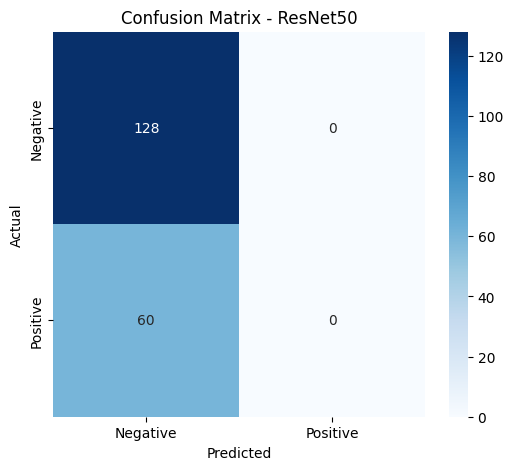

In [ ]:
# ====================
# EVALUATION METRICS
# ====================
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - ResNet50")
plt.show()



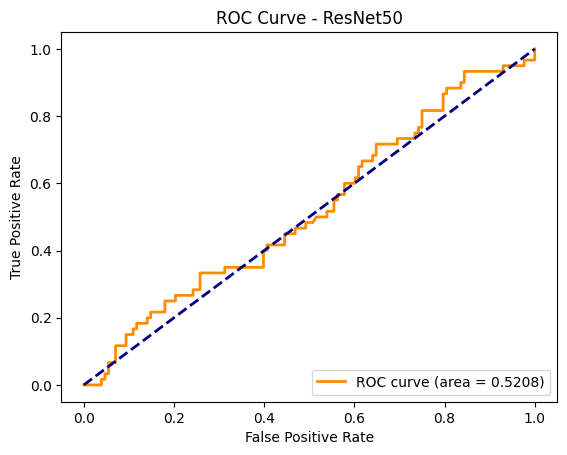

ROC AUC: 0.5208


In [ ]:
# ====================
# ROC CURVE + AUC (binary case)
# ====================
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label='ROC curve (area = {:.4f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - ResNet50')
plt.legend(loc="lower right")
plt.show()

print(f"ROC AUC: {roc_auc:.4f}")

#**MobileNeV2** (Fully Frozed -> binary classifier head)

In [ ]:
# ====================
# LOAD PRETRAINED MOBILENETV2 (binary head, frozen weights)
# ====================
base_model = tf.keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,  # Remove ImageNet classifier
    input_shape=(224, 224, 3)
)
base_model.trainable = False

x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
output_layer = tf.keras.layers.Dense(1, activation='sigmoid')(x)
binary_model = tf.keras.Model(inputs=base_model.input, outputs=output_layer)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# ====================
# PREPROCESS IMAGES FOR MOBILENETV2
# ====================
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input
dataset_prep = dataset.map(lambda x, y: (preprocess_input(x), y))


In [ ]:
# ====================
# RUN PREDICTIONS (no training)
# ====================
y_true = np.concatenate([y for _, y in dataset_prep], axis=0)
y_pred_probs = binary_model.predict(dataset_prep)
y_pred = (y_pred_probs > 0.5).astype(int).ravel()


12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 740ms/step



Classification Report:
              precision    recall  f1-score   support

    Negative     0.6768    0.5234    0.5903       128
    Positive     0.3146    0.4667    0.3758        60

    accuracy                         0.5053       188
   macro avg     0.4957    0.4951    0.4831       188
weighted avg     0.5612    0.5053    0.5219       188



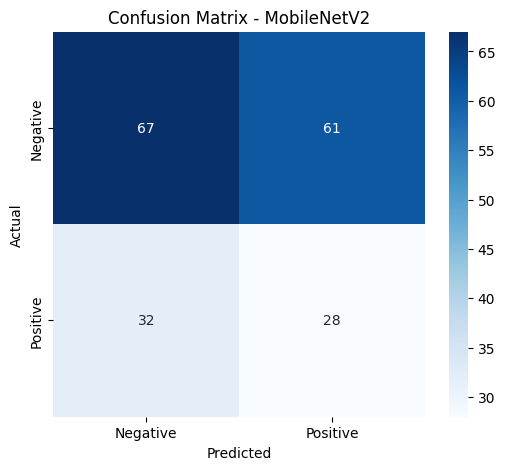

In [ ]:
# ====================
# EVALUATION METRICS
# ====================
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - MobileNetV2")
plt.show()

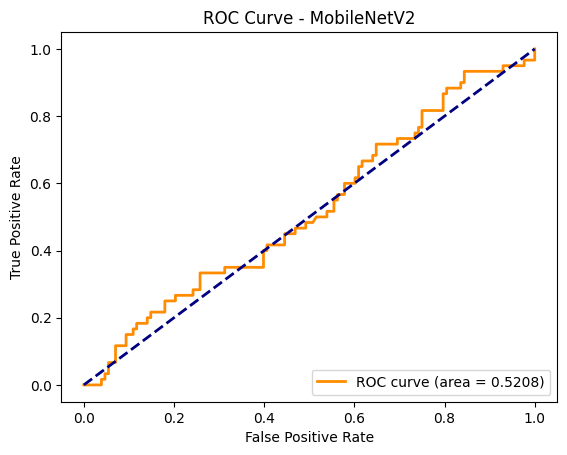

ROC AUC: 0.5208


In [ ]:
# ====================
# ROC CURVE + AUC (binary case)
# ====================
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label='ROC curve (area = {:.4f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - MobileNetV2')
plt.legend(loc="lower right")
plt.show()

print(f"ROC AUC: {roc_auc:.4f}")

#**EfficientNetB0** (Fully Frozed -> binary classifier head)

In [ ]:
# ====================
# LOAD PRETRAINED EFFICIENTNETB0 (binary head, frozen weights)
# ====================
base_model = tf.keras.applications.EfficientNetB0(
    weights="imagenet",
    include_top=False,  # Remove ImageNet classifier
    input_shape=(224, 224, 3)
)
base_model.trainable = False

x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
output_layer = tf.keras.layers.Dense(1, activation='sigmoid')(x)
binary_model = tf.keras.Model(inputs=base_model.input, outputs=output_layer)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# ====================
# PREPROCESS IMAGES FOR EFFICIENTNETB0
# ====================
preprocess_input = tf.keras.applications.efficientnet.preprocess_input
dataset_prep = dataset.map(lambda x, y: (preprocess_input(x), y))


In [ ]:
# ====================
# RUN PREDICTIONS (no training)
# ====================
y_true = np.concatenate([y for _, y in dataset_prep], axis=0)
y_pred_probs = binary_model.predict(dataset_prep)
y_pred = (y_pred_probs > 0.5).astype(int).ravel()


12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step



Classification Report:
              precision    recall  f1-score   support

    Negative     0.6739    0.9688    0.7949       128
    Positive     0.0000    0.0000    0.0000        60

    accuracy                         0.6596       188
   macro avg     0.3370    0.4844    0.3974       188
weighted avg     0.4588    0.6596    0.5412       188



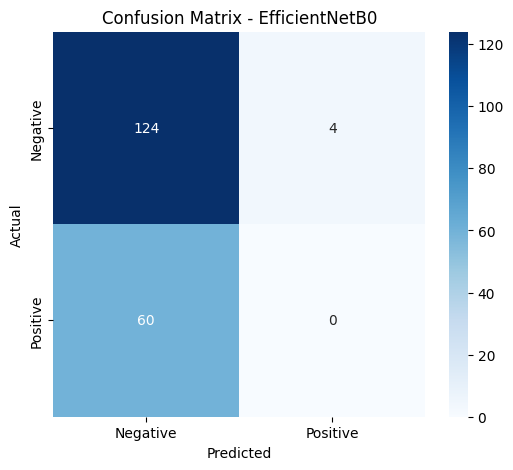

In [ ]:
# ====================
# EVALUATION METRICS
# ====================
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - EfficientNetB0")
plt.show()


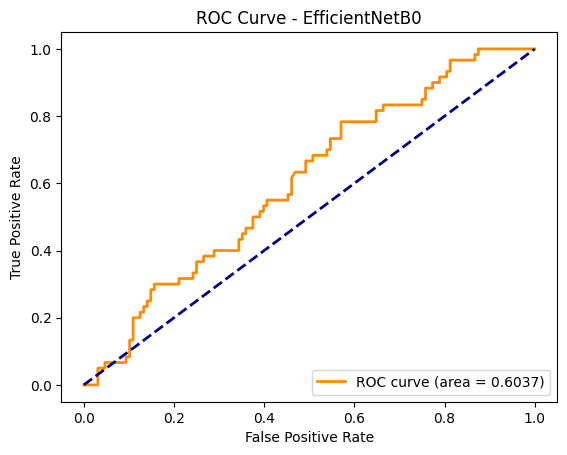

ROC AUC: 0.6037


In [ ]:
# ====================
# ROC CURVE + AUC (binary case)
# ====================
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label='ROC curve (area = {:.4f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - EfficientNetB0')
plt.legend(loc="lower right")
plt.show()

print(f"ROC AUC: {roc_auc:.4f}")


# mew
---



In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns

# ====================
# CLASS WEIGHTS
# ====================
neg, pos = class_counts[class_names[0]], class_counts[class_names[1]]
total = neg + pos
class_weight = {
    0: total / (2 * neg),  # weight for negative class
    1: total / (2 * pos)   # weight for positive class
}
print("\nClass weights:", class_weight)

# ====================
# BUILD RESNET50 MODEL
# ====================
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base model

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])




Class weights: {0: 0.734375, 1: 1.5666666666666667}
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# ====================
# TRAIN
# ====================
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5,
    class_weight=class_weight
)


Epoch 1/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 45s 4s/step - accuracy: 0.2039 - loss: 1.0876 - val_accuracy: 0.4375 - val_loss: 0.7707
Epoch 2/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 37s 4s/step - accuracy: 0.4290 - loss: 0.8353 - val_accuracy: 0.0000e+00 - val_loss: 1.4408
Epoch 3/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 45s 4s/step - accuracy: 0.3004 - loss: 0.8795 - val_accuracy: 0.0000e+00 - val_loss: 1.1813
Epoch 4/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step - accuracy: 0.1941 - loss: 0.7588 - val_accuracy: 0.0000e+00 - val_loss: 1.1245
Epoch 5/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 41s 4s/step - accuracy: 0.7146 - loss: 0.8000 - val_accuracy: 0.9375 - val_loss: 0.4300


In [ ]:

# ====================
# EVALUATE
# ====================
loss, acc = model.evaluate(test_dataset)
print(f"\nTest Accuracy: {acc:.4f}")



3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 1.0000 - loss: 0.3408

Test Accuracy: 1.0000


In [ ]:
# Get true labels
y_true = np.concatenate([y.numpy() for _, y in test_dataset])

# Predict
y_pred_prob = model.predict(test_dataset)
y_pred_prob = y_pred_prob[:len(y_true)]  # match lengths

# Convert to binary
y_pred = (y_pred_prob > 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step

Classification Report:
              precision    recall  f1-score   support

    Negative       0.74      1.00      0.85        32
    Positive       1.00      0.08      0.15        12

    accuracy                           0.75        44
   macro avg       0.87      0.54      0.50        44
weighted avg       0.81      0.75      0.66        44

